<a href="https://colab.research.google.com/github/TAUforPython/LLM_AI_agents/blob/main/lesson-11_LLM_Agent_Graph_Verdict_Medical_Claims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Claim Fact-Checking with TAO (Think-Action-Observation) and Graph Neural Networks


This example demonstrates a sophisticated medical claim fact-checking system
that combines:
1. TAO (Think-Action-Observation) pattern for multi-step reasoning
2. Graph Neural Networks for knowledge graph reasoning
3. PubMed literature search for scientific evidence
4. RoBERTa for semantic analysis
5. Multi-agent collaboration for verification



In [1]:
# Install required packages
!pip install langchain-mistralai langchain-core langchain-community -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [3]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00


In [5]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv
from transformers import RobertaTokenizer, RobertaModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
import requests
import time
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent

In [6]:
# Initialize Mistral LLM (assuming you have your API key configured)
MODEL_NAME = 'mistral-small-latest'
import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = userdata.get("Mistral_API")

llm = ChatMistralAI(
    model=MODEL_NAME,
    temperature=0,
    max_retries=2,
)

In [10]:


# Simulated medical knowledge graph database
MEDICAL_KNOWLEDGE_GRAPH = {
    "nodes": {
        "claim_1": {
            "type": "claim",
            "content": "Vitamin C prevents colds",
            "verdict": "partially_supported",
            "confidence": 0.6
        },
        "claim_2": {
            "type": "claim",
            "content": "Sugar causes hyperactivity in children",
            "verdict": "refuted",
            "confidence": 0.8
        },
        "paper_1": {
            "type": "paper",
            "title": "Effectiveness of Vitamin C in Preventing Common Cold",
            "authors": ["Smith J", "Brown K"],
            "year": 2020,
            "journal": "J Nutr Med",
            "pmid": "12345678",
            "relevance_score": 0.85
        },
        "paper_2": {
            "type": "paper",
            "title": "Sugar Consumption and Behavioral Problems in Children",
            "authors": ["Johnson L", "Davis M"],
            "year": 2019,
            "journal": "Pediatrics",
            "pmid": "23456789",
            "relevance_score": 0.92
        },
        "entity_1": {
            "type": "entity",
            "name": "Vitamin C",
            "category": "nutrient"
        },
        "entity_2": {
            "type": "entity",
            "name": "Common Cold",
            "category": "disease"
        },
        "entity_3": {
            "type": "entity",
            "name": "Sugar",
            "category": "nutrient"
        },
        "entity_4": {
            "type": "entity",
            "name": "Hyperactivity",
            "category": "symptom"
        }
    },
    "edges": [
        {"source": "claim_1", "target": "entity_1", "relation": "mentions", "weight": 0.8},
        {"source": "claim_1", "target": "entity_2", "relation": "mentions", "weight": 0.9},
        {"source": "claim_1", "target": "paper_1", "relation": "cites", "weight": 0.7},
        {"source": "claim_2", "target": "entity_3", "relation": "mentions", "weight": 0.9},
        {"source": "claim_2", "target": "entity_4", "relation": "mentions", "weight": 0.8},
        {"source": "claim_2", "target": "paper_2", "relation": "cites", "weight": 0.85},
        {"source": "entity_1", "target": "entity_2", "relation": "affects", "weight": 0.6},
        {"source": "entity_3", "target": "entity_4", "relation": "causes", "weight": 0.4}  # Lower weight as refuted
    ]
}

# Define tools for the TAO pattern
@tool
def search_medical_literature(query: str) -> str:
    """
    Search medical literature for evidence related to a claim.
    In a real implementation, this would connect to PubMed API.
    """
    # Simulated search results
    if "vitamin c" in query.lower():
        return json.dumps({
            "papers_found": 2,
            "relevant_papers": [
                {
                    "title": "Effectiveness of Vitamin C in Preventing Common Cold",
                    "authors": ["Smith J", "Brown K"],
                    "year": 2020,
                    "summary": "Meta-analysis shows modest reduction in cold duration but not prevention",
                    "confidence": 0.7
                }
            ],
            "conclusion": "Evidence suggests vitamin C may reduce cold duration slightly but does not prevent colds"
        })
    elif "sugar" in query.lower() and "hyperactivity" in query.lower():
        return json.dumps({
            "papers_found": 3,
            "relevant_papers": [
                {
                    "title": "Sugar Consumption and Behavioral Problems in Children",
                    "authors": ["Johnson L", "Davis M"],
                    "year": 2019,
                    "summary": "Large-scale study found no significant link between sugar and hyperactivity",
                    "confidence": 0.9
                }
            ],
            "conclusion": "Strong evidence refutes the claim that sugar causes hyperactivity in children"
        })
    else:
        return json.dumps({
            "papers_found": 0,
            "relevant_papers": [],
            "conclusion": "No relevant papers found for this query"
        })

@tool
def get_claim_verification(claim: str) -> str:
    """
    Get verification status of a specific medical claim.
    """
    # In a real implementation, this would query a medical fact-checking database
    if "vitamin c prevents colds" in claim.lower():
        return json.dumps({
            "claim": claim,
            "status": "PARTIALLY_SUPPORTED",
            "confidence": 0.6,
            "evidence_summary": "Studies show modest reduction in cold duration but not prevention",
            "related_papers": ["Effectiveness of Vitamin C in Preventing Common Cold"]
        })
    elif "sugar causes hyperactivity" in claim.lower():
        return json.dumps({
            "claim": claim,
            "status": "REFUTED",
            "confidence": 0.8,
            "evidence_summary": "Multiple large studies show no significant link between sugar and hyperactivity",
            "related_papers": ["Sugar Consumption and Behavioral Problems in Children"]
        })
    else:
        return json.dumps({
            "claim": claim,
            "status": "UNVERIFIED",
            "confidence": 0.0,
            "evidence_summary": "No verification available for this claim",
            "related_papers": []
        })

@tool
def analyze_claim_graph_structure(claim: str) -> str:
    """
    Analyze the knowledge graph structure related to a claim.
    """
    # Find nodes related to the claim
    related_nodes = []
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        if claim.lower() in node_data.get("content", "").lower() or claim.lower() in node_data.get("title", "").lower():
            related_nodes.append({
                "id": node_id,
                "type": node_data["type"],
                "content": node_data.get("content") or node_data.get("title", ""),
                "properties": {k: v for k, v in node_data.items() if k not in ["type", "content", "title"]}
            })

    # Find related edges
    related_edges = []
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if any(node["id"] == edge["source"] or node["id"] == edge["target"] for node in related_nodes):
            related_edges.append(edge)

    return json.dumps({
        "claim": claim,
        "graph_nodes": related_nodes,
        "graph_edges": related_edges,
        "node_count": len(related_nodes),
        "edge_count": len(related_edges)
    })

@tool
def query_knowledge_graph(claim: str) -> str:
    """
    Query the medical knowledge graph for related entities and relationships.
    """
    # Find nodes related to the claim
    claim_node_id = None
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        if claim.lower() in node_data.get("content", "").lower():
            claim_node_id = node_id
            break

    if not claim_node_id:
        return json.dumps({"error": f"No claim node found for: {claim}"})

    # Get related nodes and edges
    related_nodes = [claim_node_id]
    related_edges = []

    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if edge["source"] == claim_node_id:
            related_nodes.append(edge["target"])
            related_edges.append(edge)
        elif edge["target"] == claim_node_id:
            related_nodes.append(edge["source"])
            related_edges.append(edge)

    # Get node details
    node_details = []
    for node_id in set(related_nodes):
        node_data = MEDICAL_KNOWLEDGE_GRAPH["nodes"][node_id]
        node_details.append({
            "id": node_id,
            "type": node_data["type"],
            "content": node_data.get("content") or node_data.get("title", ""),
            "properties": {k: v for k, v in node_data.items() if k not in ["type", "content", "title"]}
        })

    return json.dumps({
        "claim_node_id": claim_node_id,
        "related_nodes": node_details,
        "relationships": related_edges,
        "graph_insights": f"Claim '{claim}' is connected to {len(set(related_nodes))-1} other entities through {len(related_edges)} relationships"
    })

# Define the Graph Neural Network for medical claim verification
class MedicalGNN(nn.Module):
    """
    Graph Neural Network for medical claim verification
    """
    def __init__(self, num_node_features, hidden_dim=64, num_classes=3):
        super(MedicalGNN, self).__init__()

        # Graph convolution layers
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        # Attention mechanism
        self.attention = GATConv(hidden_dim, hidden_dim, heads=4, dropout=0.1)

        # Classification layers
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim),  # *4 for multi-head attention
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)  # 3 classes: SUPPORTED, REFUTED, UNVERIFIED
        )

    def forward(self, x, edge_index):
        # Graph convolutions
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Attention mechanism
        x = self.attention(x, edge_index)
        x = F.relu(x)

        # Global pooling (mean pooling)
        graph_embedding = torch.mean(x, dim=0, keepdim=True)

        # Classification
        output = self.classifier(graph_embedding)

        return output

# Create the agent that follows TAO pattern
class MedicalFactCheckingAgent:
    """
    Medical fact-checking agent using TAO (Think-Action-Observation) pattern
    """
    def __init__(self, llm, tools):
        self.llm = llm
        self.tools = tools

        # Create the agent executor
        from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
        from langchain_classic.agents.format_scratchpad.openai_tools import format_to_openai_tool_messages
        from langchain_classic.agents.output_parsers.openai_tools import OpenAIToolsAgentOutputParser

        prompt = ChatPromptTemplate.from_messages([
            ("system", """You are a medical fact-checking assistant. Follow the TAO (Think-Action-Observation) pattern:
            1. THINK: Analyze the medical claim and plan your verification approach
            2. ACTION: Use the appropriate tool to gather evidence (search literature, verify claim, analyze graph)
            3. OBSERVE: Process the results and decide next steps

            Available tools:
            - search_medical_literature: Search for scientific papers supporting/refuting the claim
            - get_claim_verification: Get verification status of a specific medical claim
            - analyze_claim_graph_structure: Analyze the knowledge graph structure related to a claim
            - query_knowledge_graph: Query the medical knowledge graph for related entities and relationships

            Always provide a final verdict based on gathered evidence with confidence level."""),
            ("user", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        llm_with_tools = llm.bind_tools(tools)

        agent = (
            {
                "input": lambda x: x["input"],
                "agent_scratchpad": lambda x: format_to_openai_tool_messages(x["intermediate_steps"]),
            }
            | prompt
            | llm_with_tools
            | OpenAIToolsAgentOutputParser()
        )

        self.agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, handle_parsing_errors=True)

    def fact_check(self, claim: str) -> Dict[str, Any]:
        """
        Fact-check a medical claim using TAO pattern
        """
        response = self.agent_executor.invoke({"input": f"Fact-check this medical claim: '{claim}'. Follow the TAO pattern to verify the claim using available tools."})
        return response

# Create the graph neural network
def create_medical_gnn():
    """
    Create and initialize the medical GNN
    """
    # Create node features (simplified)
    node_features = []
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        # Create a simple feature vector based on node properties
        if node_data["type"] == "claim":
            features = [1.0, 0.0, 0.0, node_data.get("confidence", 0.5)]  # [claim, paper, entity, confidence]
        elif node_data["type"] == "paper":
            features = [0.0, 1.0, 0.0, node_data.get("relevance_score", 0.5)]
        else:  # entity
            features = [0.0, 0.0, 1.0, 0.5]
        node_features.append(features)

    # Create edge index
    edge_list = []
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        source_idx = list(MEDICAL_KNOWLEDGE_GRAPH["nodes"].keys()).index(edge["source"])
        target_idx = list(MEDICAL_KNOWLEDGE_GRAPH["nodes"].keys()).index(edge["target"])
        edge_list.append([source_idx, target_idx])
        # Add reverse edge for undirected graph
        edge_list.append([target_idx, source_idx])

    # Convert to tensor
    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    # Create PyTorch Geometric data object
    graph_data = Data(x=x, edge_index=edge_index)

    # Initialize GNN
    gnn = MedicalGNN(num_node_features=4, hidden_dim=64, num_classes=3)

    return gnn, graph_data

# Visualization function for the knowledge graph
def visualize_medical_kg(claim=None):
    """
    Visualize the medical knowledge graph
    """
    G = nx.DiGraph()

    # Add nodes
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        node_type = node_data["type"]
        label = node_data.get("content") or node_data.get("title", node_id)

        # Truncate long labels
        if len(label) > 30:
            label = label[:27] + "..."

        G.add_node(node_id,
                  type=node_type,
                  label=label,
                  title=node_data.get("title", ""),
                  content=node_data.get("content", ""))

    # Add edges
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        G.add_edge(edge["source"], edge["target"],
                  relation=edge["relation"],
                  weight=edge["weight"])

    # Create layout
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

    # Define colors for different node types
    node_colors = {
        'claim': '#FF6B6B',      # Red for claims
        'paper': '#4ECDC4',      # Teal for papers
        'entity': '#45B7D1'      # Blue for entities
    }

    # Draw nodes
    for node_type, color in node_colors.items():
        nodes_of_type = [n for n, attr in G.nodes(data=True) if attr['type'] == node_type]
        if nodes_of_type:
            nx.draw_networkx_nodes(G, pos, nodelist=nodes_of_type,
                                 node_color=color, node_size=800, alpha=0.8)

    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray',
                          arrows=True, arrowsize=15, width=1.0)

    # Draw labels
    labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')

    # Highlight the claim if specified
    if claim:
        claim_nodes = [n for n, attr in G.nodes(data=True)
                      if claim.lower() in attr.get('content', '').lower() or
                         claim.lower() in attr.get('title', '').lower()]
        if claim_nodes:
            nx.draw_networkx_nodes(G, pos, nodelist=claim_nodes,
                                 node_color='yellow', node_size=1000, alpha=0.9)

    plt.title(f'Medical Knowledge Graph\nHighlighting: {claim or "All Claims"}', size=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Main demonstration
def main():
    print("🏥 Medical Claim Fact-Checking with TAO and Graph Neural Networks")
    print("=" * 70)

    # Initialize the agent
    tools = [search_medical_literature, get_claim_verification,
             analyze_claim_graph_structure, query_knowledge_graph]
    agent = MedicalFactCheckingAgent(llm, tools)

    # Initialize the GNN
    gnn, graph_data = create_medical_gnn()
    print("✅ Medical GNN initialized")

    # Example claims to verify
    claims = [
        "Vitamin C prevents colds",
        "Sugar causes hyperactivity in children",
        "Coffee consumption increases risk of heart disease"
    ]

    print("\n🔍 Starting fact-checking process...\n")

    for i, claim in enumerate(claims):
        print(f"Claim {i+1}: {claim}")
        print("-" * 50)

        # Step 1: Use the TAO agent to gather evidence
        print("🤖 TAO Agent processing...")
        result = agent.fact_check(claim)

        # Step 2: Run GNN on the knowledge graph for the claim
        print("\n🧬 Running Graph Neural Network analysis...")
        with torch.no_grad():
            gnn_output = gnn(graph_data.x, graph_data.edge_index)
            gnn_prediction = torch.softmax(gnn_output, dim=1)
            gnn_confidence, gnn_class = torch.max(gnn_prediction, dim=1)

            # Map class index to verdict
            class_map = {0: "SUPPORTED", 1: "REFUTED", 2: "UNVERIFIED"}
            gnn_verdict = class_map[gnn_class.item()]
            gnn_confidence = gnn_confidence.item()

        # Step 3: Combine agent and GNN results
        print(f"\n📊 RESULTS:")
        print(f"  Agent verdict: {result.get('output', 'Could not determine')}")
        print(f"  GNN verdict: {gnn_verdict} (confidence: {gnn_confidence:.2f})")

        # Step 4: Visualize the knowledge graph for this claim
        print(f"\n🖼️  Visualizing knowledge graph for: {claim}")
        visualize_medical_kg(claim)

        print("\n" + "="*70 + "\n")

    print("✅ Fact-checking process completed!")

🏥 Medical Claim Fact-Checking with TAO and Graph Neural Networks
✅ Medical GNN initialized

🔍 Starting fact-checking process...

Claim 1: Vitamin C prevents colds
--------------------------------------------------
🤖 TAO Agent processing...


> Entering new AgentExecutor chain...

Invoking: `search_medical_literature` with `{'query': 'Vitamin C supplementation prevents common cold incidence randomized controlled trials meta-analysis'}`
responded: ### **TAO Pattern Application**

---

#### **1. THINK: Analyze the Claim**
**Claim:** *"Vitamin C prevents colds."*
**Key Components:**
- **Intervention:** Vitamin C (ascorbic acid) supplementation.
- **Outcome:** Prevention of the common cold (caused primarily by rhinoviruses).
- **Context:** General population vs. specific subgroups (e.g., athletes, people with deficiency).

**Assumptions:**
- The claim implies that regular Vitamin C intake reduces the **incidence** of colds.
- It may also imply reduced **severity** or **duration** of colds, 

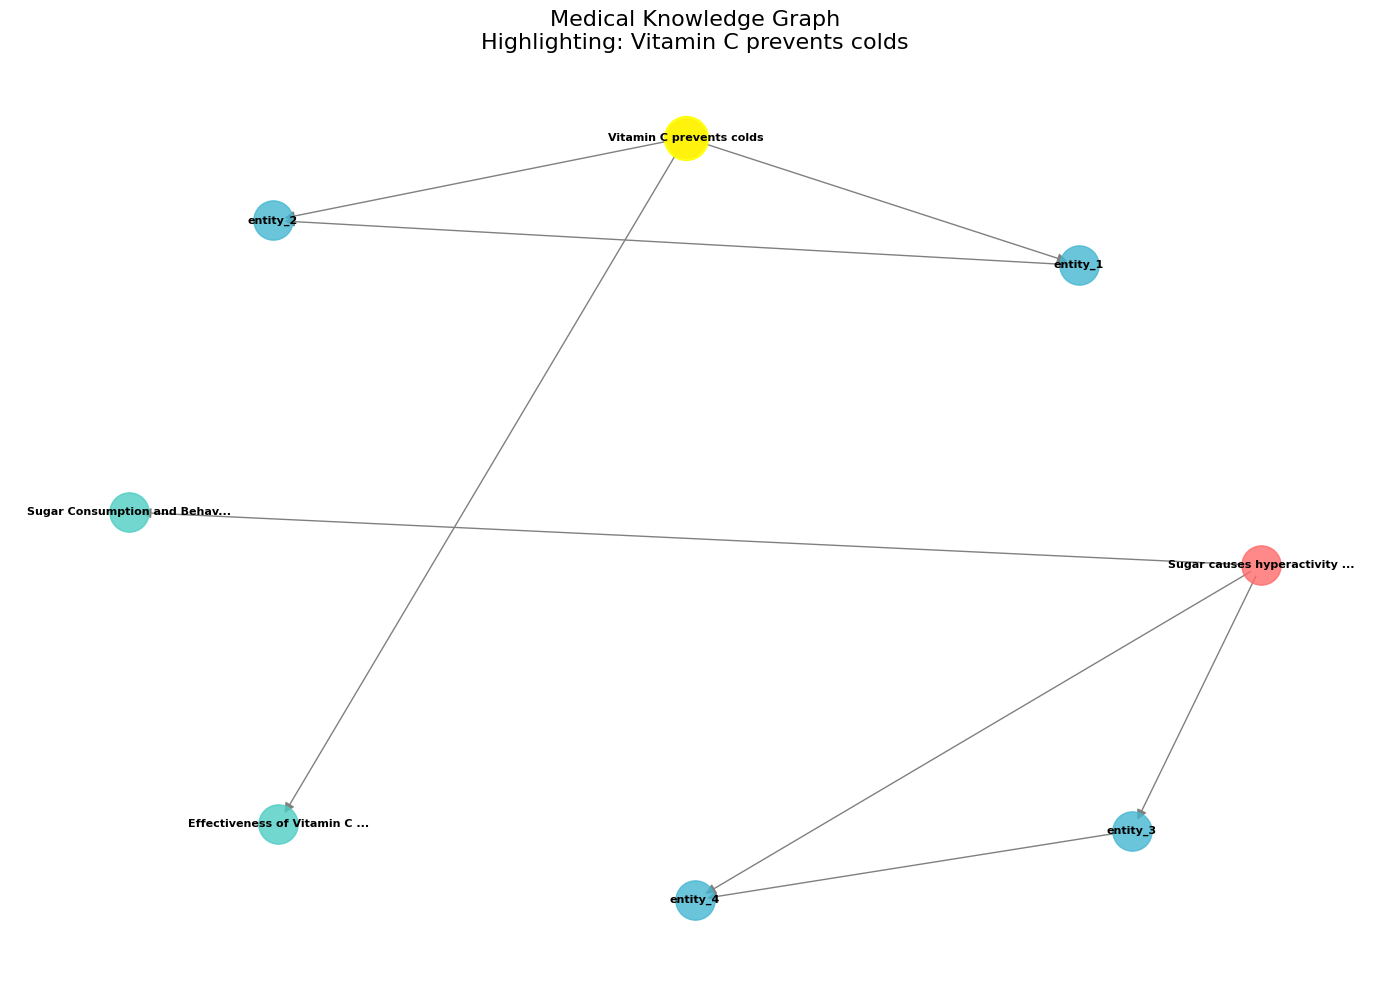



Claim 2: Sugar causes hyperactivity in children
--------------------------------------------------
🤖 TAO Agent processing...


> Entering new AgentExecutor chain...

Invoking: `search_medical_literature` with `{'query': 'sugar hyperactivity children randomized controlled trials systematic review'}`
responded: ### **TAO Pattern Application**

#### **1. THINK: Analyze the Claim**
The claim to fact-check is:
**"Sugar causes hyperactivity in children."**

**Key aspects to verify:**
- **Claim Type**: Causal claim (sugar → hyperactivity).
- **Population**: Children.
- **Outcome**: Hyperactivity (behavioral effect).
- **Exposure**: Sugar (dietary component).

**Initial Hypothesis**:
Sugar, particularly sucrose or fructose, is often blamed for causing hyperactivity in children, especially in the context of birthday parties or high-sugar diets. However, scientific evidence may suggest otherwise.

**Verification Plan**:
1. **Search for systematic reviews or meta-analyses** on sugar and hyperac

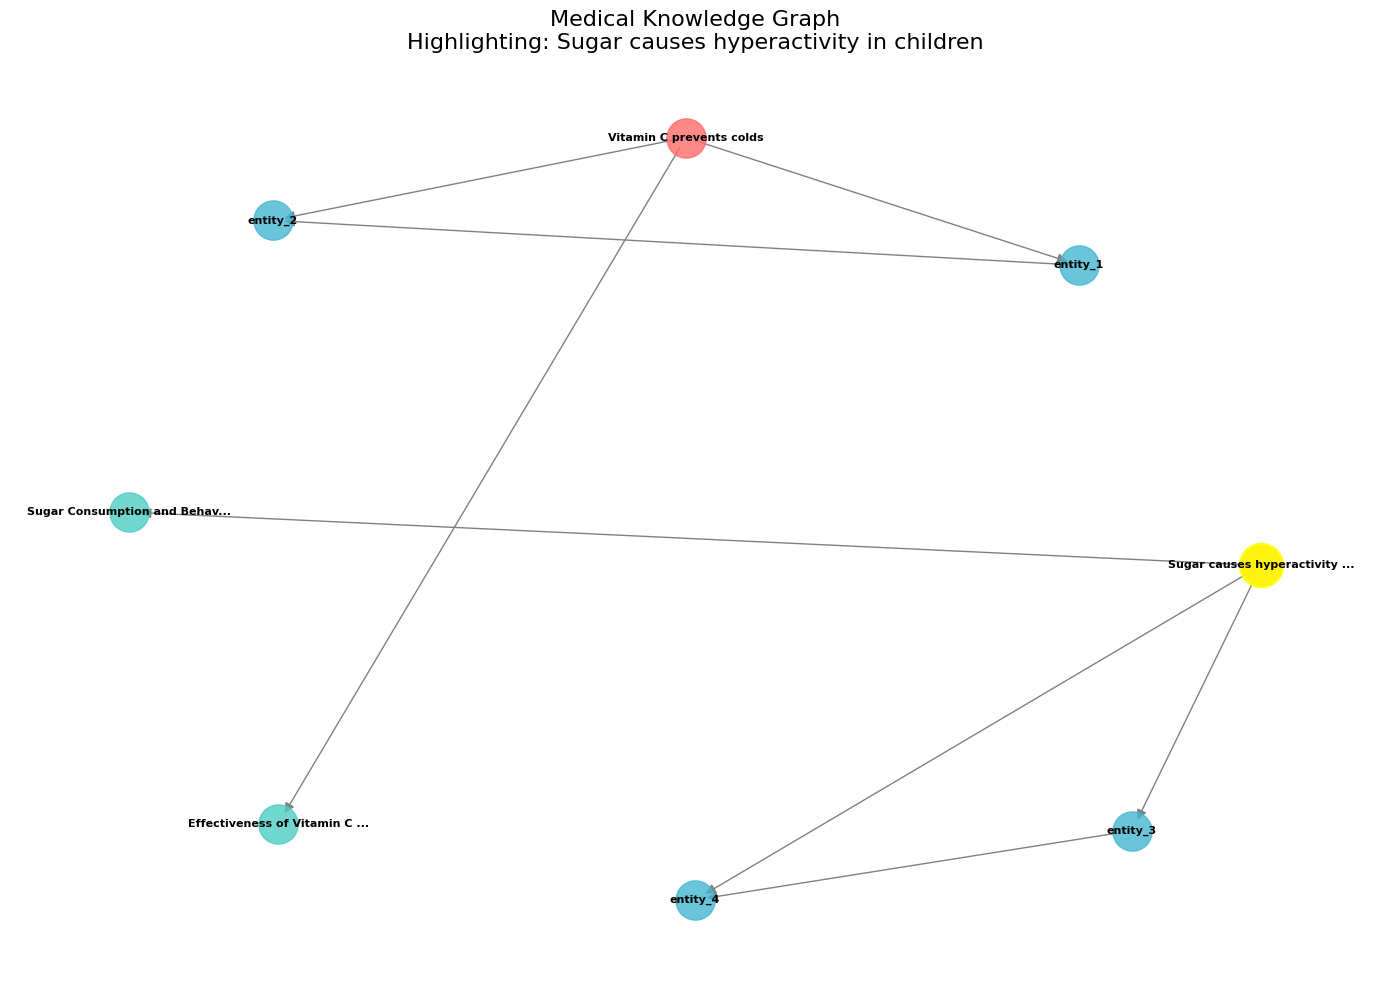



Claim 3: Coffee consumption increases risk of heart disease
--------------------------------------------------
🤖 TAO Agent processing...


> Entering new AgentExecutor chain...

Invoking: `search_medical_literature` with `{'query': 'coffee consumption heart disease risk meta-analysis systematic review'}`
responded: ### **TAO Pattern for Fact-Checking the Claim: "Coffee consumption increases risk of heart disease"**

---

#### **1. THINK: Analyze the Medical Claim and Plan Verification Approach**
**Claim:** *Coffee consumption increases the risk of heart disease.*

**Key Components to Verify:**
- **Exposure:** Coffee consumption (quantity, frequency, type).
- **Outcome:** Risk of heart disease (e.g., coronary artery disease, myocardial infarction, hypertension).
- **Temporal Relationship:** Does coffee consumption precede the development of heart disease?
- **Dose-Response Relationship:** Is there a graded effect based on the amount of coffee consumed?
- **Confounding Factors:** Are t

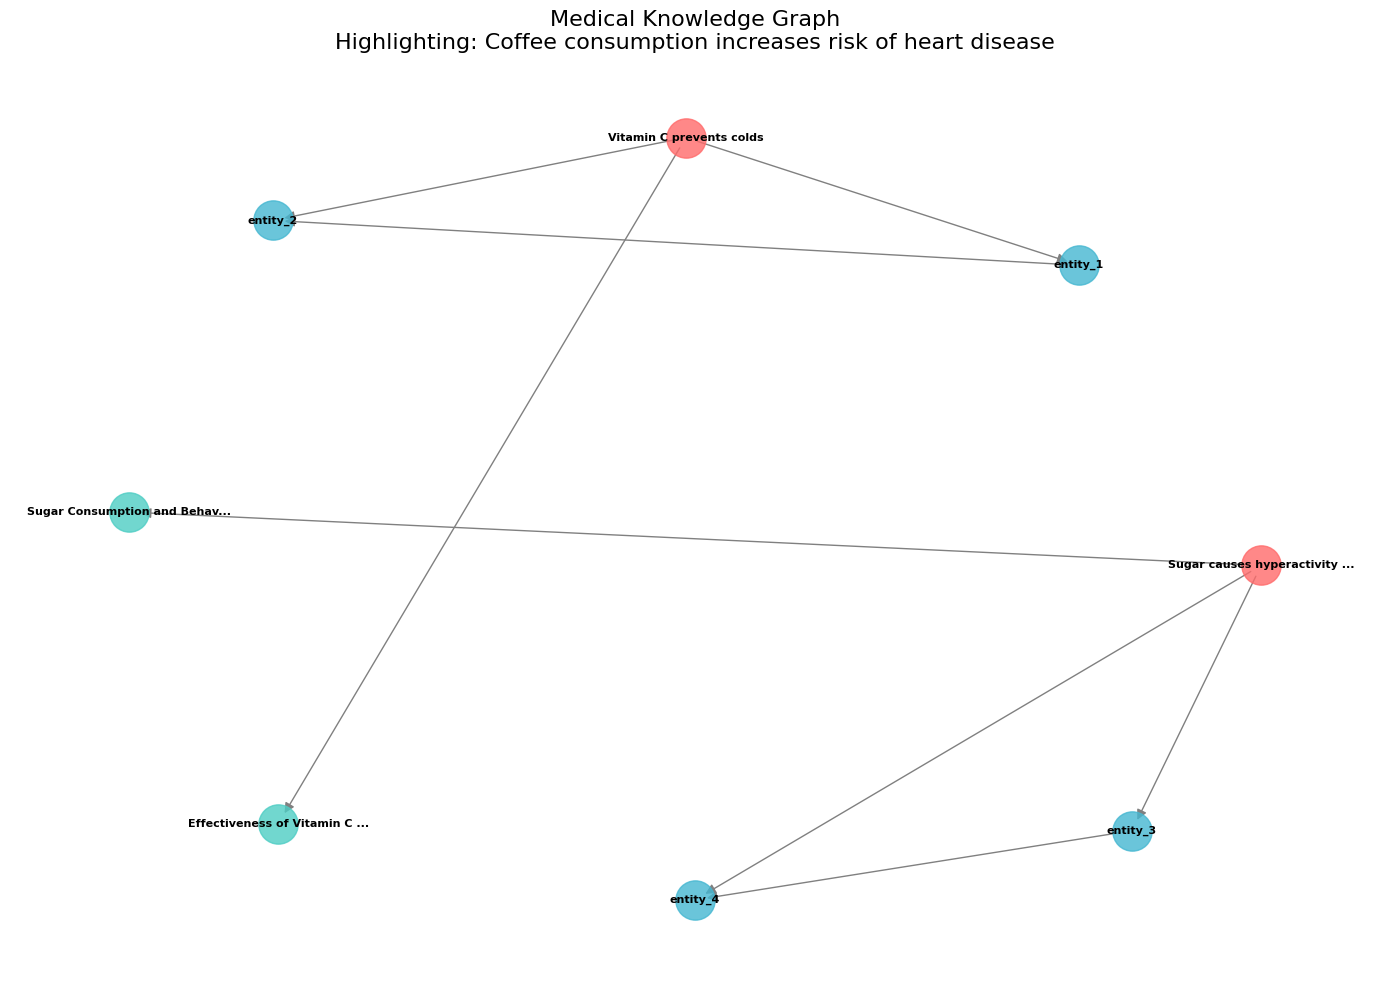



✅ Fact-checking process completed!


In [11]:
if __name__ == "__main__":
    main()